In [1]:
import torch
import qewton
import matplotlib.pyplot as plt

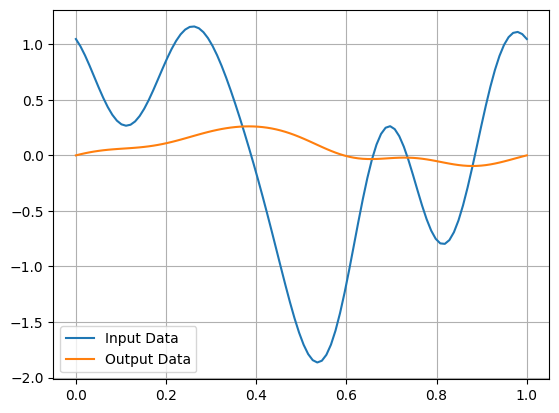

In [2]:
input_data = torch.load("../data/integrator/f_data.pt", weights_only=True)
output_data = torch.load("../data/integrator/u_data.pt", weights_only=True)
x_data = torch.load("../data/integrator/x_data.pt", weights_only=True)
x_data = torch.repeat_interleave(x_data.unsqueeze(0), repeats=5000, dim=0)

train_in_data, train_out_data, train_x_data = input_data[:4000], output_data[:4000], x_data[:4000]
test_in_data, test_out_data, test_x_data = input_data[4000:], output_data[4000:], x_data[4000:]

batch_size = 1000

plt.plot(x_data[0], input_data[0].numpy(), label="Input Data")
plt.plot(x_data[0], output_data[0].numpy(), label="Output Data")
plt.grid()
plt.legend()

In [3]:
F = qewton.config.Variable("f", 1)
X = qewton.config.Variable("x", 1)
U = qewton.config.Variable("u", 1)

x_config = qewton.config.DataConfiguration(
    qewton.config.BatchAxes(batch_size), 
    qewton.config.GeometryAxes(shape=(100, )), 
    qewton.config.FeatureAxes(X)
)

input_config = qewton.config.DataConfiguration(
    qewton.config.BatchAxes(batch_size), 
    qewton.config.GeometryAxes(shape=(100, )), 
    qewton.config.FeatureAxes(F)
)
output_config = qewton.config.DataConfiguration(
    qewton.config.BatchAxes(batch_size), 
    qewton.config.GeometryAxes(shape=(100, )), 
    qewton.config.FeatureAxes(U)
)

dataset = qewton.data.ArrayLikeDataSet(
    data=[train_in_data, train_x_data, train_out_data], 
    data_configs=[input_config, x_config, output_config]
)


In [4]:
data_loader = qewton.data.DataLoader(
    data_set=dataset,
    batch_size=batch_size,
    splitting_ratio=(1.0, 0.0, 0.0),
    shuffle_data=False,
)

In [5]:
model = qewton.algorithms.FCNDeepONet(
    trunk_input=X, 
    branch_input=F,
    output=U,
    trunk_hidden_neurons=16,
    branch_hidden_neurons=16,
    trunk_hidden_layers=3,
    branch_hidden_layers=2,
    intermediate_neurons=32,
)

In [6]:
constraint = qewton.constraints.MSEConstraint()
computation_graph = qewton.Graph()
computation_graph.connect(data_loader.get_output_port(F), model.branch_port)
computation_graph.connect(data_loader.get_output_port(X), model.trunk_port)
computation_graph.connect(model, constraint.input_1)
computation_graph.connect(data_loader.get_output_port(U), constraint.input_2)

In [7]:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.001,
    max_iterations=2500,
)

trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase],
    graphs=[computation_graph],
    training_objectives=[constraint],
    device="cuda:0",
)

trainer.run()

Optimization Phase 1: 100%|██████████| 2500/2500 [01:48<00:00, 22.94it/s, loss=0.000525] 


Test MSE: 0.0005739862681366503


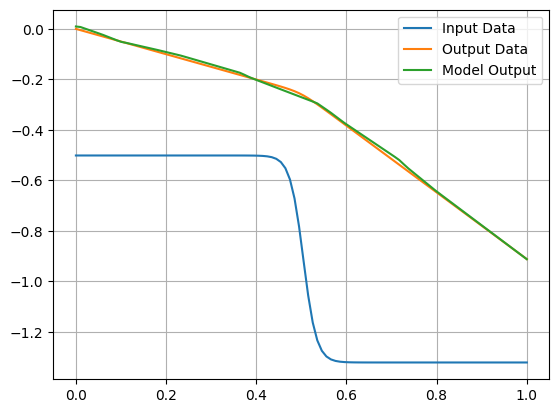

In [9]:
model.to("cpu")
model_out_test = model(test_in_data, test_x_data)
error = torch.mean((model_out_test - test_out_data) ** 2)
print(f"Test MSE: {error.item()}")

idx = 28
plt.plot(test_x_data[idx], test_in_data[idx], label="Input Data")
plt.plot(test_x_data[idx], test_out_data[idx], label="Output Data")
plt.plot(test_x_data[idx], model_out_test[idx].detach().cpu().numpy(), label="Model Output")
plt.grid()
plt.legend()